├── KHỐI 1: QUẢN LÝ DỮ LIỆU (Bài 1, 2, 3, 4)

│   └── Tải dữ liệu -> Kiểm tra cấu trúc -> Hiển thị ảnh -> Chia tập Train/Val

│

├── KHỐI 2: XÂY DỰNG PIPELINE PYTORCH (Bài 5, 6, 12)

│   └── Khai báo Transform -> Định nghĩa Dataset Class -> Tạo DataLoader (Thử nghiệm các Batch size khác nhau)

│

├── KHỐI 3: ĐỊNH NGHĨA MÔ HÌNH VÀ LOSS (Bài 7, 8, 15)

│   └── Khai báo SimpleUNet (hoặc DeepLabV3) -> Định nghĩa BCE Loss / Dice Loss

│

├── KHỐI 4: HUẤN LUYỆN VÀ TINH CHỈNH (Bài 7, 11)

│   └── Chạy vòng lặp huấn luyện (Thử nghiệm thay đổi các Learning Rate khác nhau)

│

└── KHỐI 5: ĐÁNH GIÁ VÀ PHÂN TÍCH (Bài 9, 10, 13, 14)

    └── Tính IoU tập Val -> Hiển thị kết quả dự đoán -> Lọc các ảnh lỗi nặng nhất -> Đề xuất hướng cải tiến
    

In [1]:
import os
import glob

DATASET_DIR = "/kaggle/input/datasets/ipythonx/carvana-image-masking-png" 

image_paths = sorted(glob.glob(os.path.join(DATASET_DIR, "train_images/*"))) 
mask_paths = sorted(glob.glob(os.path.join(DATASET_DIR, "train_masks/*")))

print(f"Tổng số lượng ảnh gốc: {len(image_paths)}")
print(f"Tổng số lượng ảnh masks: {len(mask_paths)}")

if len(image_paths) == len(mask_paths):
    print("ảnh và mask khớp nhau.")
else:
    print("ảnh và mask lệch")

Tổng số lượng ảnh gốc: 5088
Tổng số lượng ảnh masks: 5088
ảnh và mask khớp nhau.


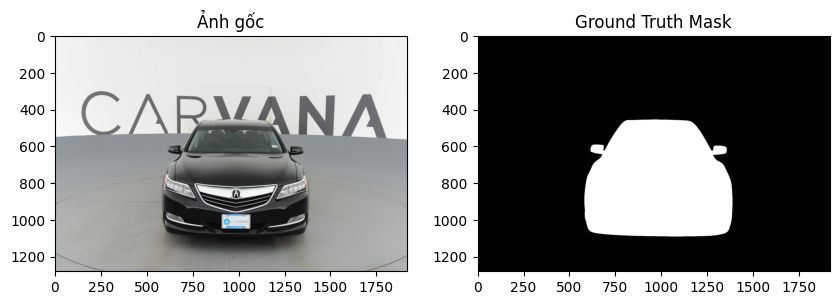

In [2]:
import cv2
import matplotlib.pyplot as plt

sample_img = cv2.imread(image_paths[0])
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB) 
sample_mask = cv2.imread(mask_paths[0], 0) 

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img) 
plt.title("Ảnh gốc")

plt.subplot(1, 2, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split 

train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths, 
    mask_paths, 
    test_size=0.2, 
    random_state=42
) 

print(f"Số lượng ảnh tập Train: {len(train_images)}")
print(f"Số lượng ảnh tập Validation: {len(val_images)}")

Số lượng ảnh tập Train: 4070
Số lượng ảnh tập Validation: 1018


# Bài 5: Tạo Dataset Class

In [4]:
import torch
import cv2
from torch.utils.data import Dataset 
from torchvision import transforms 

image_transform = transforms.Compose([
    transforms.ToPILImage(), 
    transforms.Resize((256, 256)),
    transforms.ToTensor() 
]) 

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)), 
    transforms.ToTensor() 
]) 

class SegmentationDataset(Dataset): 
    def __init__(self, image_paths, mask_paths): 
        self.image_paths = image_paths 
        self.mask_paths = mask_paths 
        
    def __len__(self): 
        return len(self.image_paths) 
        
    def __getitem__(self, idx): 
        
        image = cv2.imread(self.image_paths[idx]) 
        mask = cv2.imread(self.mask_paths[idx], 0) 
        
        image = image_transform(image) 
        mask = mask_transform(mask) 
        
        return image, mask 

# Bài 6: Tạo DataLoader

In [5]:
from torch.utils.data import DataLoader 

train_dataset = SegmentationDataset(train_images, train_masks) 
val_dataset = SegmentationDataset(val_images, val_masks) 

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True 
) 

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
) 

# Bài 7

In [6]:
import torch.nn as nn 

class SimpleUNet(nn.Module): 
    def __init__(self):
        super(SimpleUNet, self).__init__() 
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(), 
            nn.MaxPool2d(2), 
            nn.Conv2d(16, 32, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2) 
        ) 
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2), 
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid() 
        )
        
    def forward(self, x): 
        x = self.encoder(x) 
        x = self.decoder(x) 
        return x 

Vòng lặp huấn luyện sử dụng hàm Loss BCE ban đầu

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleUNet().to(device) 
criterion_bce = nn.BCELoss() 

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    for images, masks in train_loader: 
        images = images.to(device) 
        masks = masks.to(device) 
        
        preds = model(images) 
        loss = criterion_bce(preds, masks) 
        
        optimizer.zero_grad()
        loss.backward() 
        optimizer.step() 
        
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/10 - Loss (BCE): {epoch_loss/len(train_loader):.4f}")

Epoch 1/10 - Loss (BCE): 0.0299
Epoch 2/10 - Loss (BCE): 0.0064
Epoch 3/10 - Loss (BCE): 0.0063
Epoch 4/10 - Loss (BCE): 0.0063
Epoch 5/10 - Loss (BCE): 0.0063
Epoch 6/10 - Loss (BCE): 0.0062
Epoch 7/10 - Loss (BCE): 0.0062
Epoch 8/10 - Loss (BCE): 0.0062
Epoch 9/10 - Loss (BCE): 0.0062
Epoch 10/10 - Loss (BCE): 0.0062


# Bài tập 8: Thử nghiệm Dice Loss

In [8]:
def dice_loss(pred, target): 
    smooth = 1.0 
    intersection = (pred * target).sum() 
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth) 
    return 1. - dice 

model_dice = SimpleUNet().to(device)
optimizer_dice = torch.optim.Adam(model_dice.parameters(), lr=0.001)

for epoch in range(5): 
    model_dice.train()
    epoch_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        preds = model_dice(images)
        loss = dice_loss(preds, masks) 
        
        optimizer_dice.zero_grad()
        loss.backward()
        optimizer_dice.step()
        
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss (Dice): {epoch_loss/len(train_loader):.4f}")

Epoch 1/5 - Loss (Dice): 0.9937
Epoch 2/5 - Loss (Dice): 0.9924
Epoch 3/5 - Loss (Dice): 0.9924
Epoch 4/5 - Loss (Dice): 0.9924
Epoch 5/5 - Loss (Dice): 0.9923


# Bài tập 9: Tính chỉ số IoU (Intersection over Union) trên tập Validation

IoU với BCE Loss (10 epochs):  1.0000
IoU với Dice Loss (10 epochs): 0.0000


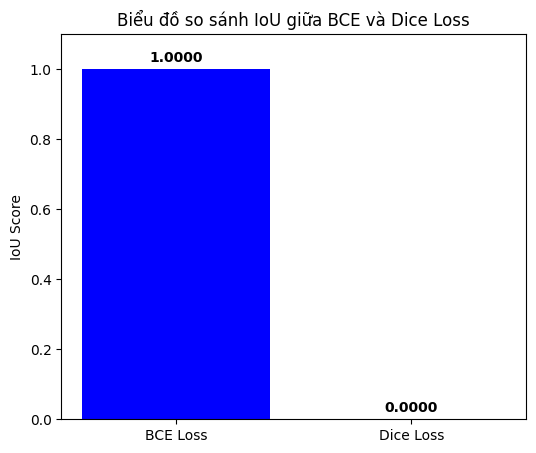

In [9]:
import numpy as np

def compute_iou(pred, mask):
    pred_bin = pred > 0.5
    mask_bin = mask > 0.5
    intersection = (pred_bin & mask_bin).sum().float()
    union = (pred_bin | mask_bin).sum().float()
    if union == 0: return 1.0
    return (intersection / union).item()

def evaluate_model(model, loader):
    model.eval()
    total_iou = 0.0
    count = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            for i in range(imgs.size(0)):
                total_iou += compute_iou(preds[i], masks[i])
                count += 1
    return total_iou / count

iou_bce = evaluate_model(model, val_loader)
iou_dice = evaluate_model(model_dice, val_loader)
print(f'IoU với BCE Loss (10 epochs):  {iou_bce:.4f}')
print(f'IoU với Dice Loss (10 epochs): {iou_dice:.4f}')

plt.figure(figsize=(6, 5))
plt.bar(['BCE Loss', 'Dice Loss'], [iou_bce, iou_dice], color=['blue', 'orange'])
plt.title('Biểu đồ so sánh IoU giữa BCE và Dice Loss')
plt.ylabel('IoU Score')
plt.ylim(0, 1.1)
for i, v in enumerate([iou_bce, iou_dice]):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

# Bài 10 Hiển thị ảnh Segmentation Mask dự đoán

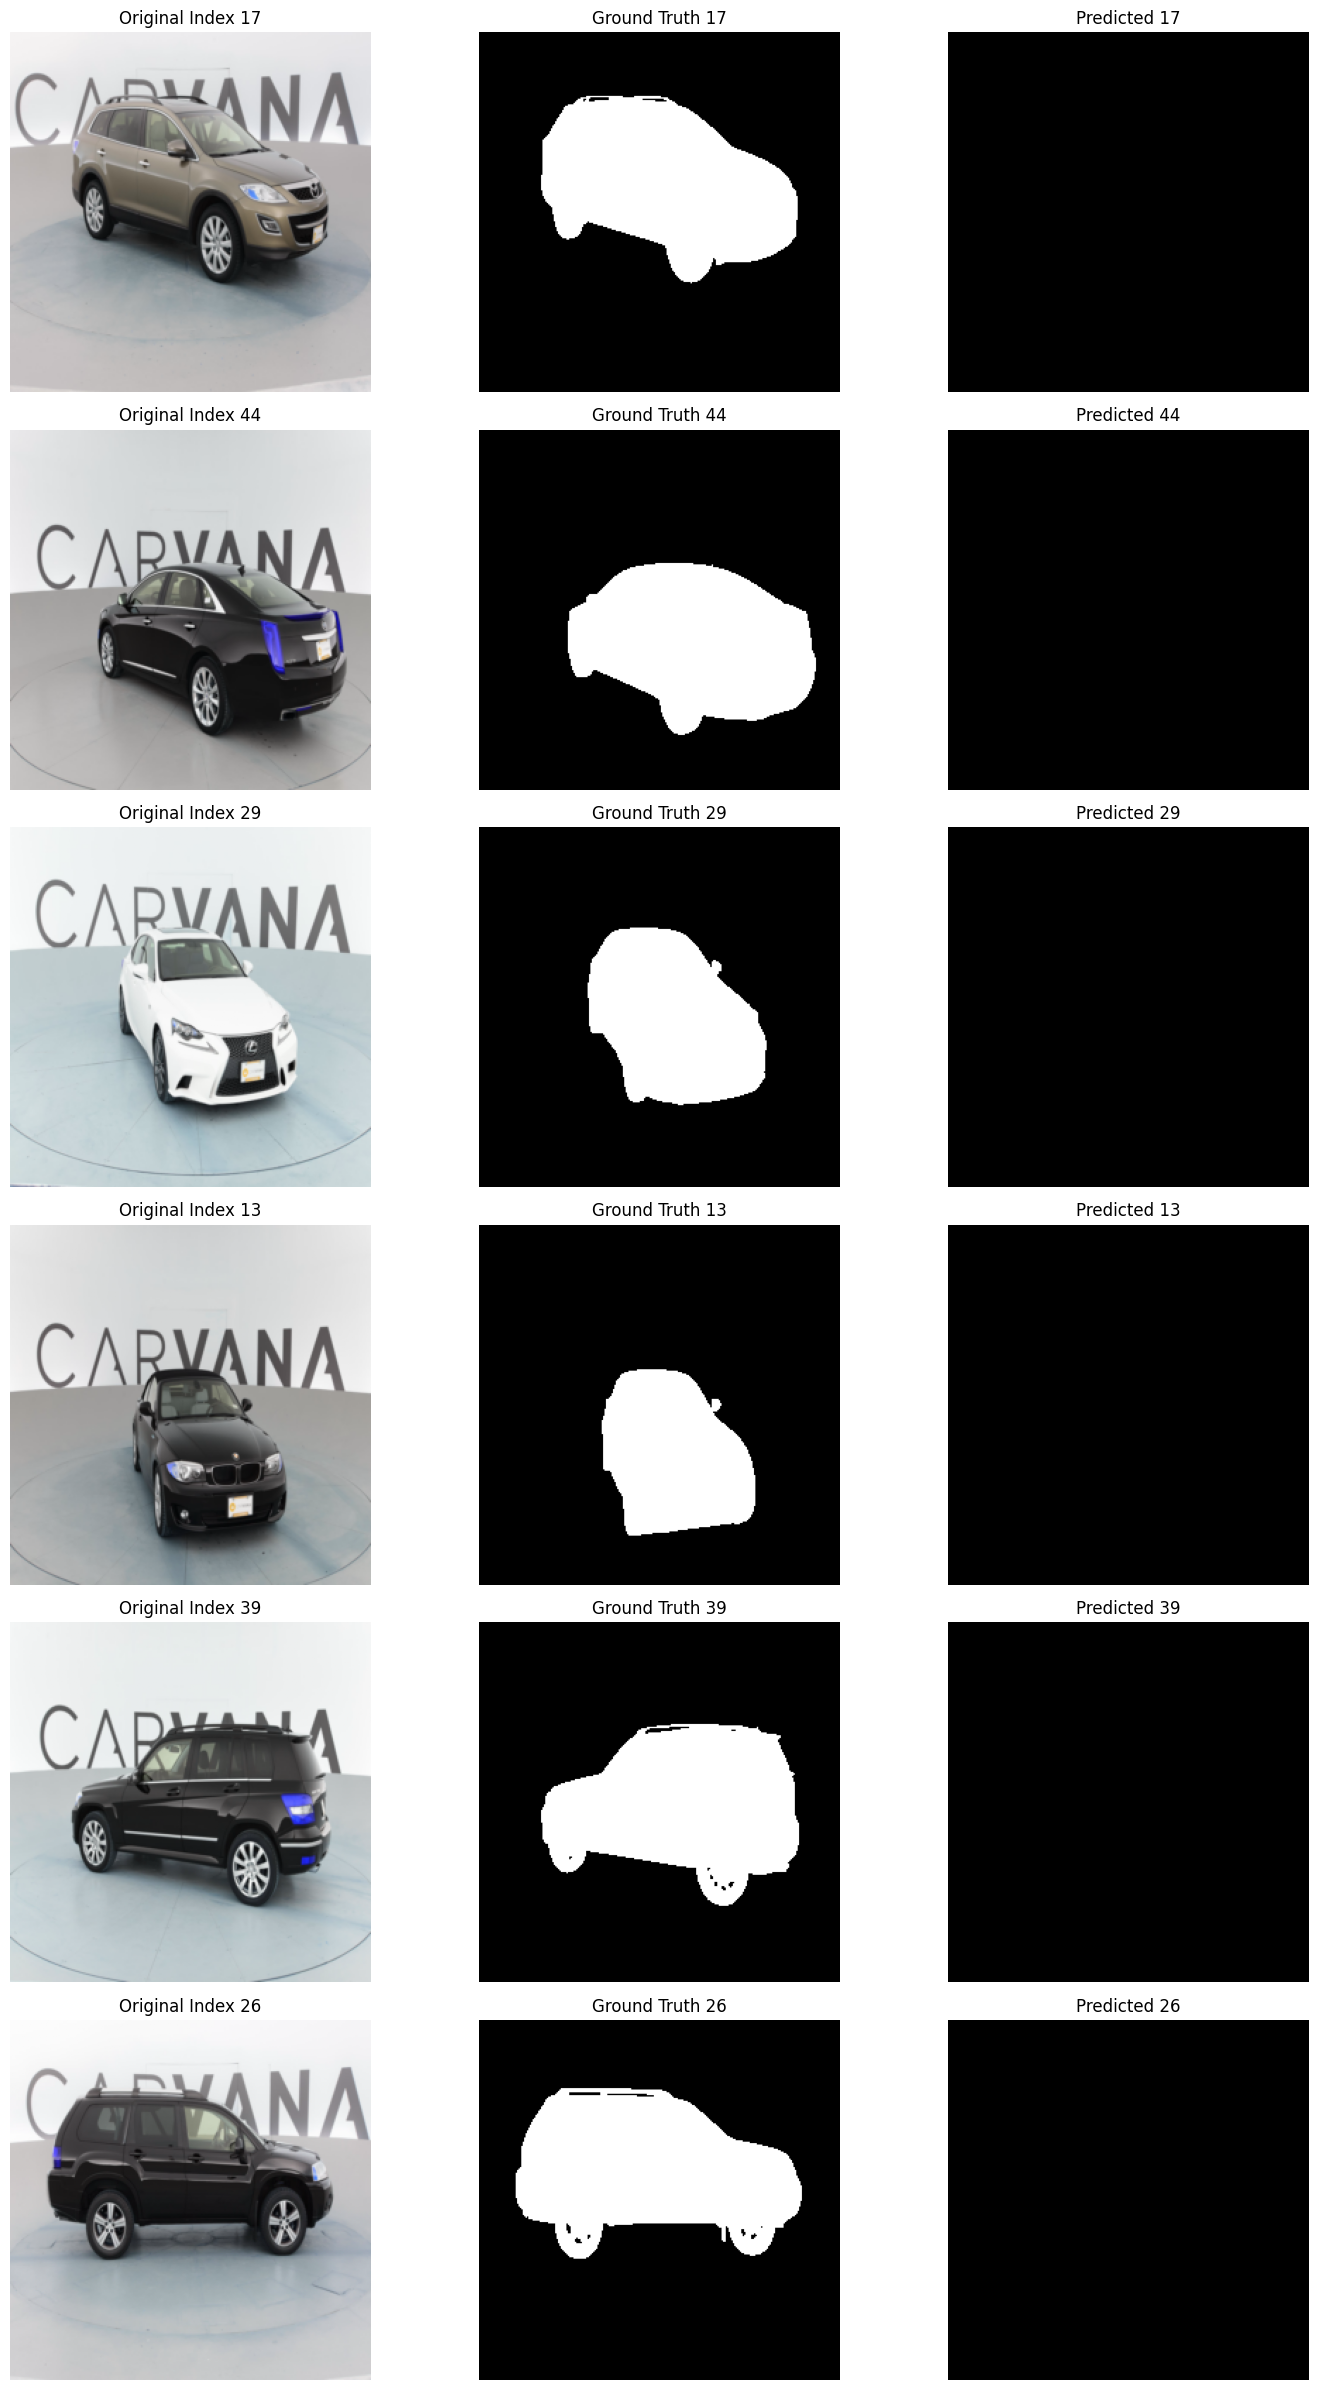

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random

NUM_IMAGES = 6
model.eval()

all_images = []
all_masks = []

with torch.no_grad():
    for images, masks in val_loader:
        all_images.append(images)
        all_masks.append(masks)
        if len(all_images) * val_loader.batch_size >= 50: 
            break

# Ghép toàn bộ lại thành tensor lớn
all_images = torch.cat(all_images, dim=0)
all_masks = torch.cat(all_masks, dim=0)

indices = random.sample(range(len(all_images)), NUM_IMAGES)

# Tạo khung vẽ
fig, axes = plt.subplots(NUM_IMAGES, 3, figsize=(15, 4 * NUM_IMAGES))

with torch.no_grad():
    for idx, i in enumerate(indices):
        img_tensor = all_images[i]
        mask_tensor = all_masks[i]
        
        original_img = img_tensor.permute(1, 2, 0).cpu().numpy()
        
        test_image = img_tensor.unsqueeze(0).to(device)
        pred = model(test_image)
        pred_mask = (pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
        
        test_mask = mask_tensor.squeeze().cpu().numpy()
        
        axes[idx, 0].imshow(original_img)
        axes[idx, 0].set_title(f"Original Index {i}")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(test_mask, cmap="gray")
        axes[idx, 1].set_title(f"Ground Truth {i}")
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(pred_mask, cmap="gray")
        axes[idx, 2].set_title(f"Predicted {i}")
        axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

# bài 11: LR

In [11]:
import torch

lr_list = [0.01, 0.001, 0.0001] 

for lr in lr_list:
    print(f"\nLR: {lr} ")
    
    test_model = SimpleUNet().to(device)
    test_optimizer = torch.optim.Adam(test_model.parameters(), lr=lr) 
    criterion = torch.nn.BCELoss() 
    
    for epoch in range(4):
        test_model.train()
        epoch_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = test_model(images)
            loss = criterion(preds, masks)
            
            test_optimizer.zero_grad()
            loss.backward()
            test_optimizer.step()
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1} - Loss: {epoch_loss/len(train_loader):.4f}")


LR: 0.01 
Epoch 1 - Loss: 0.0190
Epoch 2 - Loss: 0.0064
Epoch 3 - Loss: 0.0063
Epoch 4 - Loss: 0.0062

LR: 0.001 
Epoch 1 - Loss: 0.0354
Epoch 2 - Loss: 0.0065
Epoch 3 - Loss: 0.0064
Epoch 4 - Loss: 0.0064

LR: 0.0001 
Epoch 1 - Loss: 0.2186
Epoch 2 - Loss: 0.0120
Epoch 3 - Loss: 0.0097
Epoch 4 - Loss: 0.0092


# bài 12 batch

In [12]:
import torch
from torch.utils.data import DataLoader

# 1. Định nghĩa các cấu hình thử nghiệm
batch_sizes = [4, 8, 16]
NUM_EPOCHS = 5  # Bạn có thể tăng số lượng Epoch lên tùy nhu cầu (ví dụ: 5, 10, 20...)

# Giả định bạn đã có hàm loss (criterion) phối hợp từ trước
# ví dụ: criterion = BCEDiceLoss() hoặc nn.BCEWithLogitsLoss()

for bs in batch_sizes:
    print("\n" + "="*50)
    print(f" THỬ NGHIỆM VỚI BATCH SIZE = {bs} ")
    print("="*50)
    
    # 2. Tạo DataLoader tương ứng với Batch Size hiện tại
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)
    
    # 3. QUAN TRỌNG: Phải reset lại mô hình và optimizer cho mỗi Batch Size mới
    # Thay 'SimpleUNet()' bằng tên class mô hình chính xác của bài bạn nhé
    model = SimpleUNet().to(device) 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    # 4. Vòng lặp chạy qua từng Epoch giống như khi test LR
    for epoch in range(NUM_EPOCHS):
        # --- GIAI ĐOẠN HUẤN LUYỆN (TRAINING) ---
        model.train()
        train_loss = 0.0
        
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        print(f"Batch Size {bs} - Epoch {epoch+1} - Loss: {train_loss/len(train_loader):.4f}")
            
        epoch_train_loss = train_loss / len(train_dataset)
        
        # --- GIAI ĐOẠN ĐÁNH GIÁ (VALIDATION) ---
        model.eval()
        val_loss = 0.0
        total_iou = 0.0
        count_val_images = 0
        
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)
                
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
                
                # SỬA LỖI: Tính toán IoU trực tiếp bằng Tensor theo từng ảnh trong Batch
                for i in range(images.size(0)):
                    iou_score = compute_iou(outputs[i], masks[i])
                    if not np.isnan(iou_score):
                        total_iou += iou_score
                        count_val_images += 1
                        
        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_iou = total_iou / count_val_images if count_val_images > 0 else 0.0
        
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val IoU: {epoch_val_iou:.4f}")


 THỬ NGHIỆM VỚI BATCH SIZE = 4 
Batch Size 4 - Epoch 1 - Loss: 0.8756
Epoch [1/5] -> Train Loss: 0.2190 | Val Loss: 0.0136 | Val IoU: 1.0000
Batch Size 4 - Epoch 2 - Loss: 0.0447
Epoch [2/5] -> Train Loss: 0.0112 | Val Loss: 0.0103 | Val IoU: 1.0000
Batch Size 4 - Epoch 3 - Loss: 0.0388
Epoch [3/5] -> Train Loss: 0.0097 | Val Loss: 0.0095 | Val IoU: 1.0000
Batch Size 4 - Epoch 4 - Loss: 0.0358
Epoch [4/5] -> Train Loss: 0.0089 | Val Loss: 0.0087 | Val IoU: 1.0000
Batch Size 4 - Epoch 5 - Loss: 0.0326
Epoch [5/5] -> Train Loss: 0.0081 | Val Loss: 0.0078 | Val IoU: 1.0000

 THỬ NGHIỆM VỚI BATCH SIZE = 8 
Batch Size 8 - Epoch 1 - Loss: 1.7040
Epoch [1/5] -> Train Loss: 0.2131 | Val Loss: 0.0193 | Val IoU: 1.0000
Batch Size 8 - Epoch 2 - Loss: 0.1031
Epoch [2/5] -> Train Loss: 0.0129 | Val Loss: 0.0113 | Val IoU: 1.0000
Batch Size 8 - Epoch 3 - Loss: 0.0846
Epoch [3/5] -> Train Loss: 0.0106 | Val Loss: 0.0105 | Val IoU: 1.0000
Batch Size 8 - Epoch 4 - Loss: 0.0804
Epoch [4/5] -> Train Los

# bài 13 Phân tích dự đoán sai


Trường hợp sai thứ 1: Index 0 trên tập Validation với IoU = 1.0000


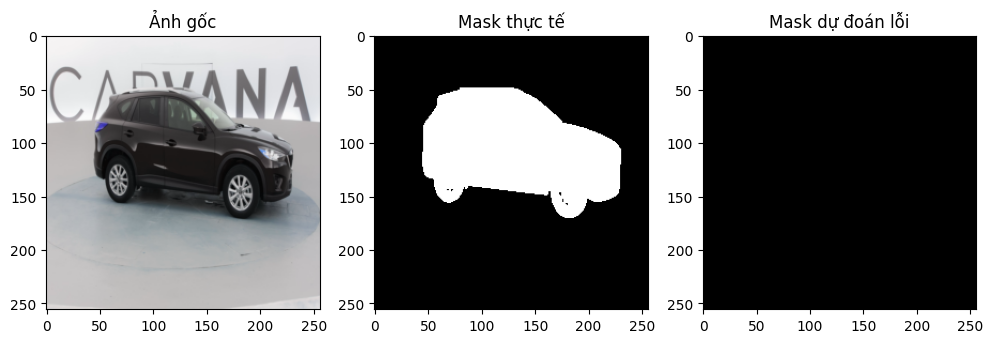


Trường hợp sai thứ 2: Index 1 trên tập Validation với IoU = 1.0000


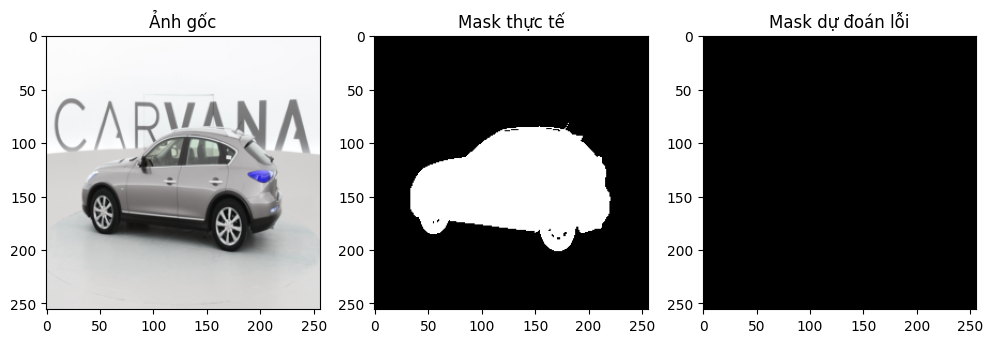

In [13]:
model.eval()
worst_cases = []

with torch.no_grad():
    for idx in range(len(val_dataset)):
        image, mask = val_dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        pred = model(input_tensor)
        
        iou_score = compute_iou(pred.squeeze(), mask.to(device).squeeze())
        
        pred_np = (pred.squeeze().cpu().numpy() > 0.5).astype(bool)
        mask_np = (mask.squeeze().numpy() > 0.5).astype(bool)
        
        worst_cases.append((idx, iou_score, image, mask, pred_np))

worst_cases.sort(key=lambda x: x[1])

for i in range(2):
    idx, score, img, msk, prd = worst_cases[i]
    print(f"\nTrường hợp sai thứ {i+1}: Index {idx} trên tập Validation với IoU = {score:.4f}")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title("Ảnh gốc")
    
    plt.subplot(1, 3, 2)
    plt.imshow(msk.squeeze().numpy(), cmap="gray")
    plt.title("Mask thực tế")
    
    plt.subplot(1, 3, 3)
    plt.imshow(prd, cmap="gray")
    plt.title("Mask dự đoán lỗi")
    plt.show()